# 🩺 Exploratory Data Analysis — Pediatric Appendicitis

Analysis of the Regensburg Pediatric Appendicitis dataset from UCI ML Repository.

In [14]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

from src.data_processing import load_data, optimize_memory, clean_data, preprocess_data, get_class_distribution

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# --- Couleurs harmonisées ---
C_APP = '#ef4444'   # rouge — appendicite
C_SAIN = '#10b981'  # vert  — sain
C_NEUTRE = '#6366f1' # violet — neutre

# --- Répertoire de sauvegarde ---
FIG_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# --- Unités médicales ---
UNITS = {
    'Age': 'ans',
    'BMI': 'kg/m\u00b2',
    'Body_Temperature': '\u00b0C',
    'WBC_Count': '10\u00b3/\u00b5L',
    'CRP': 'mg/L',
    'Neutrophil_Percentage': '%',
    'Appendix_Diameter': 'mm',
    'Height': 'cm',
    'Weight': 'kg',
    'RBC_Count': '10\u2076/\u00b5L',
    'Hemoglobin': 'g/dL',
    'Thrombocyte_Count': '10\u00b3/\u00b5L',
    'RDW': '%',
}

def label_with_unit(col):
    return f"{col} ({UNITS[col]})" if col in UNITS else col

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Dataset

In [15]:
df = load_data()
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

2026-03-10 13:13:17,821 [INFO] Loading dataset from local file: /home/rudolf/Coding-week-project/notebooks/../data/appendicitis.csv


Shape: (782, 54)
Columns: ['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Coprostasis', 'Meteorism', 'Enteritis', 'Gynecological_Findings', 'Diagnosis']


,Age,BMI,Sex,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,Migratory_Pain,Lower_Right_Abd_Pain,Contralateral_Rebound_Tenderness,Coughing_Pain,Nausea,Loss_of_Appetite,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,Neutrophilia,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,US_Performed,Free_Fluids,Appendix_Wall_Layers,Target_Sign,Appendicolith,Perfusion,Perforation,Surrounding_Tissue_Reaction,Appendicular_Abscess,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings,Diagnosis
0,12.68,16.9,female,148.0,37.0,3.0,4.0,3.0,yes,7.1,no,yes,yes,no,no,yes,37.0,7.7,68.2,NaN,no,5.27,14.8,12.2,254.0,++,+,no,0.0,no,normal,no,yes,no,yes,no,intact,NaN,suspected,NaN,no,yes,no,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,appendicitis
1,14.10,31.9,male,147.0,69.5,2.0,5.0,4.0,no,NaN,yes,yes,yes,no,no,yes,36.9,8.1,64.8,NaN,no,5.26,15.7,12.7,151.0,no,no,no,3.0,yes,normal,no,yes,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,no appendicitis
2,14.14,23.3,female,163.0,62.0,4.0,5.0,3.0,no,NaN,no,yes,yes,no,no,no,36.6,13.2,74.8,NaN,no,3.98,11.4,12.2,300.0,no,no,no,3.0,no,constipation,no,yes,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,yes,NaN,no appendicitis
3,16.37,20.6,female,165.0,56.0,3.0,7.0,6.0,no,NaN,yes,yes,no,no,yes,yes,36.0,11.4,63.0,NaN,no,4.64,13.6,13.2,258.0,no,no,no,0.0,yes,normal,no,yes,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN,no appendicitis
4,11.08,16.9,female,163.0,45.0,3.0,5.0,6.0,yes,7.0,no,yes,yes,yes,yes,yes,36.9,8.1,44.0,NaN,no,4.44,12.6,13.6,311.0,no,no,no,0.0,no,constipation,no,yes,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN,appendicitis


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    str    
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_on_US                    777 non-null    str    
 9   Appendix_Diameter                 498 non-null    float64
 10  Migratory_Pain                    773 non-null    str    
 11  Lower_Right_Abd_Pain              774 non-null    str    
 12  Contralateral_Rebou

In [17]:
df.describe()

,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP
count,781.000000,755.000000,756.000000,779.000000,778.000000,730.000000,730.000000,498.000000,775.000000,776.000000,679.000000,54.000000,764.000000,764.000000,756.000000,764.000000,771.000000
mean,11.346451,18.907012,148.017460,43.172542,4.284062,5.921918,5.253425,7.762651,37.404516,12.670683,71.791163,64.929630,4.799490,13.380497,13.180291,285.252618,31.386900
std,3.529909,4.385331,19.732016,17.390984,2.574057,2.155972,1.958456,2.536671,0.903678,5.366525,14.463656,15.085025,0.499012,1.393271,4.538774,72.494373,57.433854
min,0.000000,7.830000,53.000000,3.960000,1.000000,0.000000,0.000000,2.700000,26.900000,2.600000,27.200000,32.000000,3.620000,8.200000,11.200000,91.000000,0.000000
25%,9.200000,15.725000,137.000000,29.500000,3.000000,4.000000,4.000000,6.000000,36.800000,8.200000,61.400000,54.500000,4.537500,12.600000,12.300000,236.000000,1.000000
50%,11.440000,18.060000,149.650000,41.400000,3.000000,6.000000,5.000000,7.500000,37.200000,12.000000,75.500000,64.500000,4.780000,13.300000,12.700000,276.000000,7.000000
75%,14.100000,21.180000,163.000000,54.000000,5.000000,8.000000,7.000000,9.100000,37.900000,16.200000,83.600000,77.500000,5.020000,14.000000,13.300000,330.000000,33.000000
max,18.360000,38.160000,192.000000,103.000000,28.000000,10.000000,10.000000,17.000000,40.200000,37.700000,97.700000,91.000000,14.000000,36.000000,86.900000,708.000000,365.000000


## 2. Missing Values Analysis

In [18]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
print(f'Columns with missing values: {len(missing_df)}/{len(df.columns)}')
missing_df

Columns with missing values: 54/54


,Count,Percentage
Abscess_Location,769,98.3
Gynecological_Findings,756,96.7
Conglomerate_of_Bowel_Loops,739,94.5
Segmented_Neutrophils,728,93.1
Ileus,722,92.3
Perfusion,719,91.9
Enteritis,716,91.6
Appendicolith,713,91.2
Coprostasis,711,90.9
Perforation,701,89.6


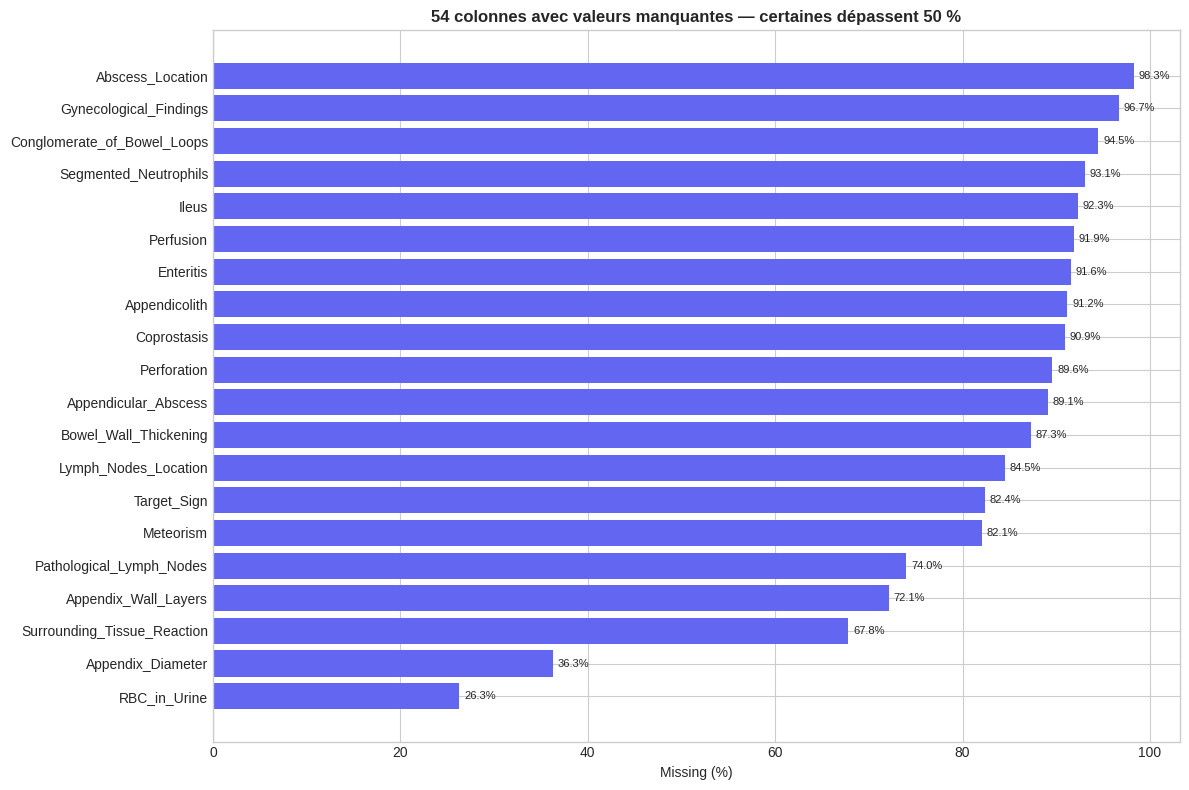

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))
top_missing = missing_df.head(20)
ax.barh(range(len(top_missing)), top_missing['Percentage'], color=C_NEUTRE)
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing.index)
ax.set_xlabel('Missing (%)')
ax.set_title(f'{len(missing_df)} colonnes avec valeurs manquantes \u2014 certaines d\u00e9passent 50 %',
             fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top_missing['Percentage']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Class Balance (Target Variable)

Target Distribution:
Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64

Percentages:
Diagnosis
appendicitis       59.2
no appendicitis    40.5
Name: count, dtype: float64


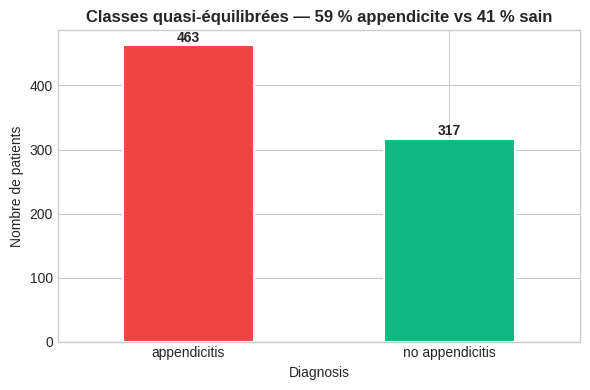


=> Dataset is approximately balanced (~59% appendicitis, ~41% no appendicitis).
=> Using class_weight="balanced" in models as a precaution.


In [20]:
print('Target Distribution:')
target_dist = df['Diagnosis'].value_counts()
print(target_dist)
print(f'\nPercentages:')
print((target_dist / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 4))
colors_bar = [C_SAIN if 'no' in str(l).lower() else C_APP for l in target_dist.index]
target_dist.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white', linewidth=1.5)
pct_app = (target_dist.get('appendicitis', 0) / len(df) * 100)
ax.set_title(f'Classes quasi-\u00e9quilibr\u00e9es \u2014 {pct_app:.0f} % appendicite vs {100-pct_app:.0f} % sain',
             fontweight='bold')
ax.set_ylabel('Nombre de patients')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(target_dist):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n=> Dataset is approximately balanced (~59% appendicitis, ~41% no appendicitis).')
print('=> Using class_weight="balanced" in models as a precaution.')

## 4. Outlier Analysis

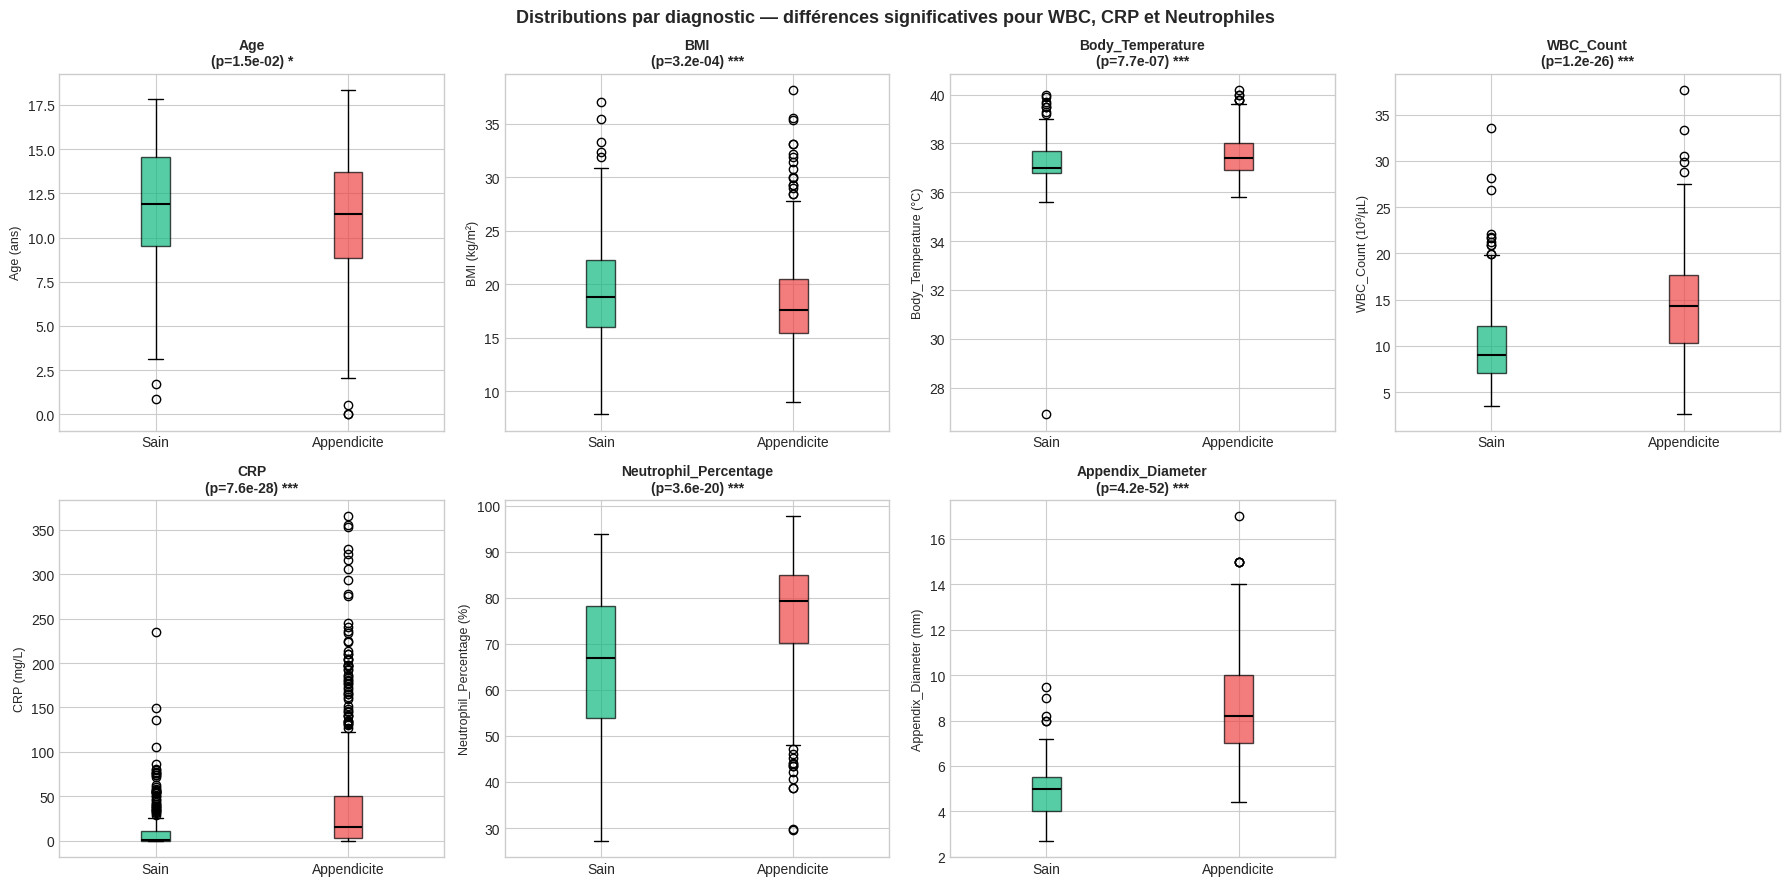

=> Outliers capped via IQR method to preserve data.


In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
key_features = ['Age', 'BMI', 'Body_Temperature', 'WBC_Count', 'CRP', 'Neutrophil_Percentage', 'Appendix_Diameter']
available = [c for c in key_features if c in numeric_cols]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(available):
    if i < len(axes):
        grp_app = df.loc[df['Diagnosis'] == 'appendicitis', col].dropna()
        grp_sain = df.loc[df['Diagnosis'] == 'no appendicitis', col].dropna()

        bp = axes[i].boxplot(
            [grp_sain, grp_app], vert=True, patch_artist=True,
            tick_labels=['Sain', 'Appendicite'],
            medianprops=dict(color='black', linewidth=1.5),
        )
        bp['boxes'][0].set_facecolor(C_SAIN)
        bp['boxes'][1].set_facecolor(C_APP)
        for box in bp['boxes']:
            box.set_alpha(0.7)

        if len(grp_app) > 0 and len(grp_sain) > 0:
            stat, pval = mannwhitneyu(grp_app, grp_sain, alternative='two-sided')
            sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
            axes[i].set_title(f'{col}\n(p={pval:.1e}) {sig}', fontsize=10, fontweight='bold')
        else:
            axes[i].set_title(col, fontsize=10, fontweight='bold')

        axes[i].set_ylabel(label_with_unit(col), fontsize=9)

for j in range(len(available), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions par diagnostic \u2014 diff\u00e9rences significatives pour WBC, CRP et Neutrophiles',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'boxplots_by_diagnosis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('=> Outliers capped via IQR method to preserve data.')

## 5. Correlation Analysis

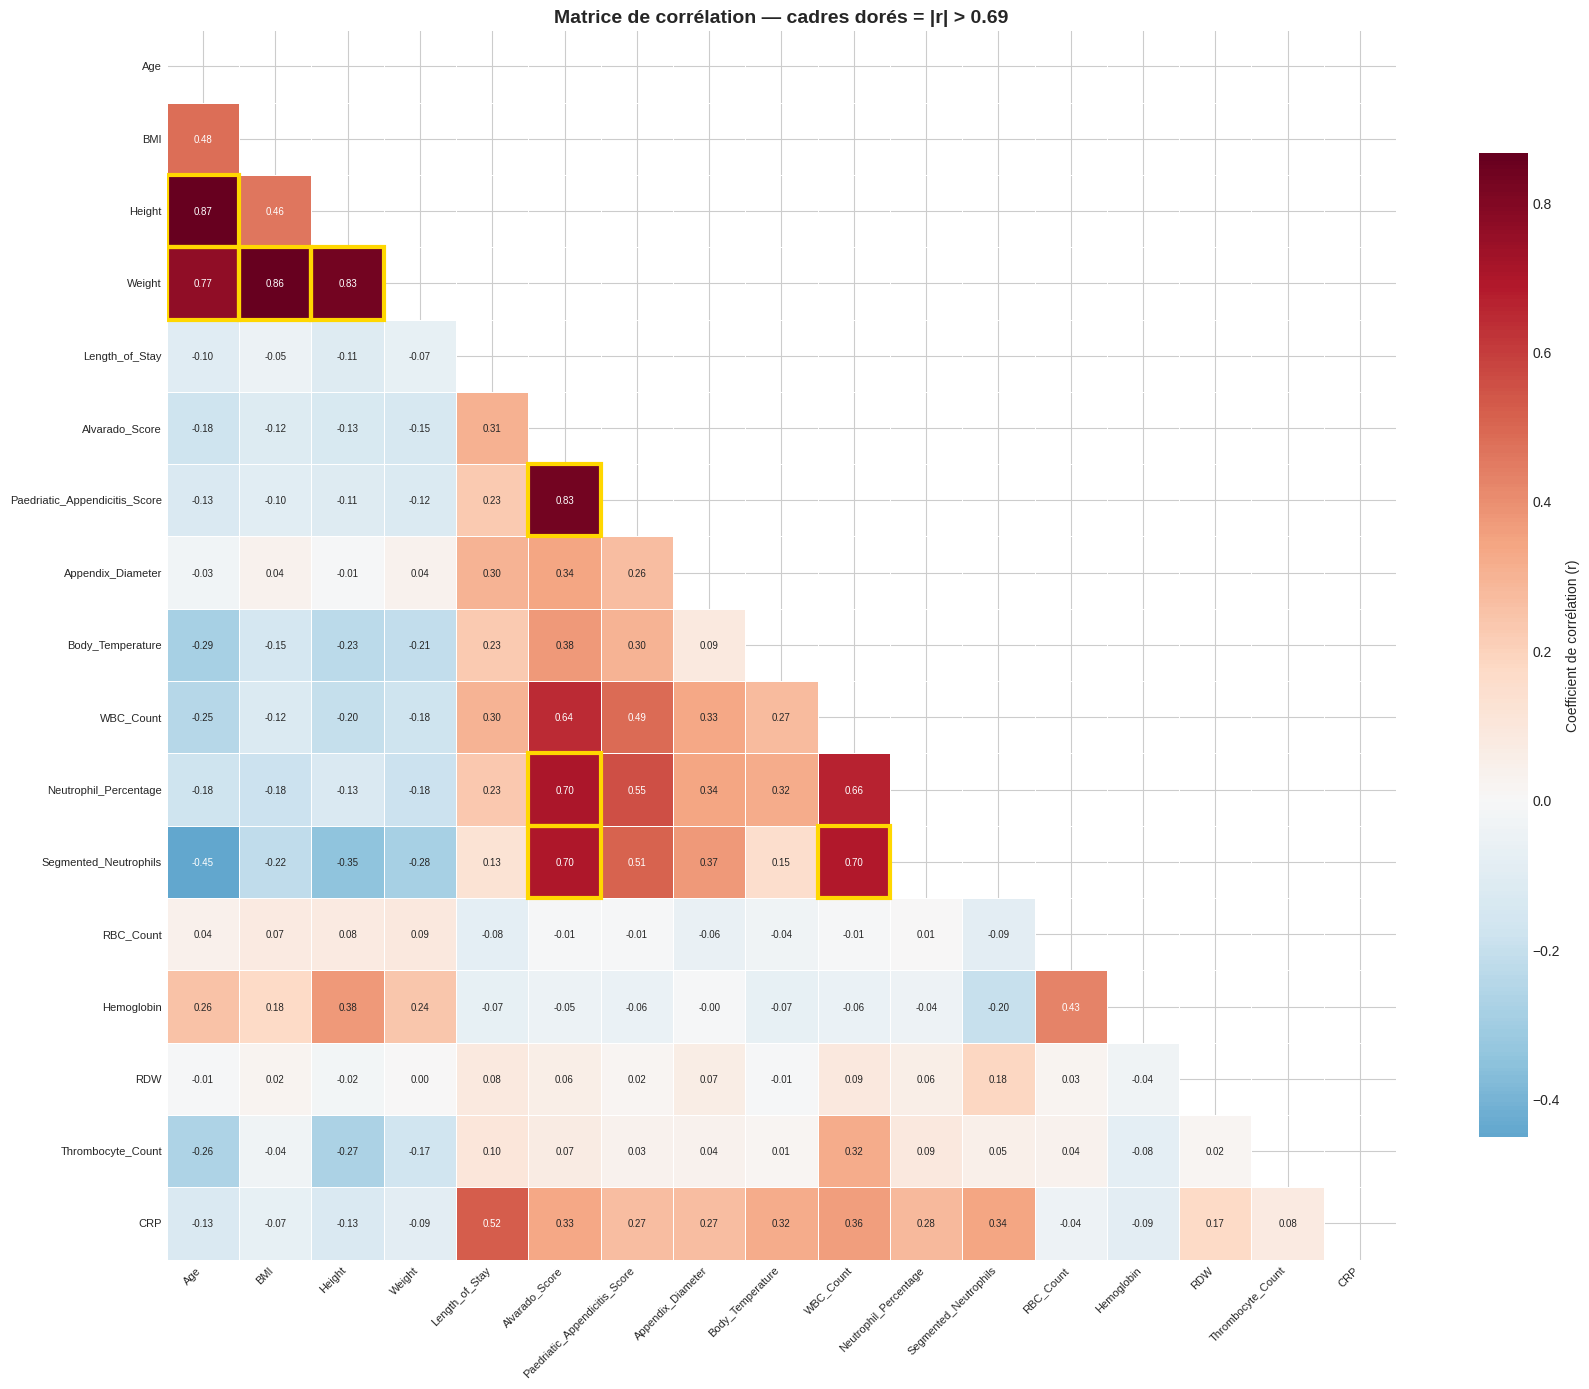

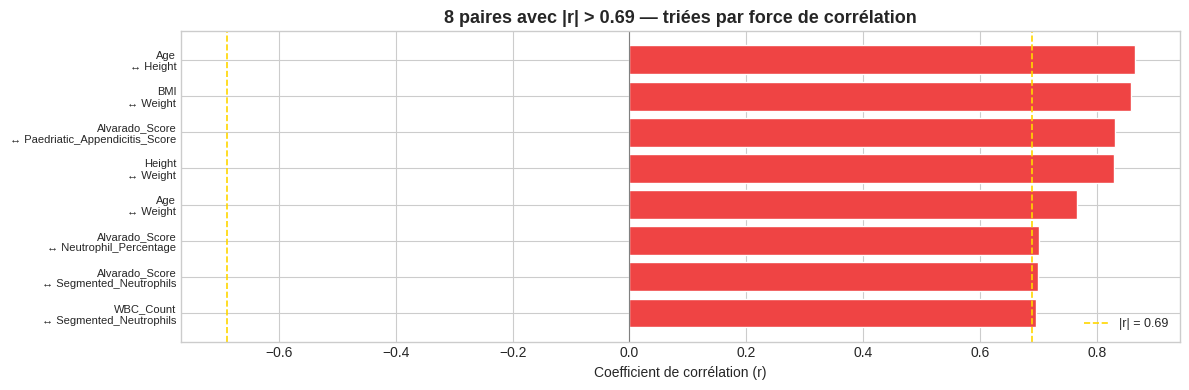

Paires fortement corrélées (|r| > 0.69):
  Age <-> Height: r=0.865
  BMI <-> Weight: r=0.859
  Alvarado_Score <-> Paedriatic_Appendicitis_Score: r=0.832
  Height <-> Weight: r=0.83
  Age <-> Weight: r=0.766
  Alvarado_Score <-> Neutrophil_Percentage: r=0.701
  Alvarado_Score <-> Segmented_Neutrophils: r=0.699
  WBC_Count <-> Segmented_Neutrophils: r=0.696


In [26]:
# --- Matrice de corr\u00e9lation compl\u00e8te (toutes variables num\u00e9riques) ---
all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
corr_full = df[all_numeric].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_full, dtype=bool))

sns.heatmap(corr_full, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8, 'label': 'Coefficient de corr\u00e9lation (r)'})

# Surligner les cellules |r| > 0.69
for i in range(len(corr_full)):
    for j in range(i):
        val = corr_full.iloc[i, j]
        if abs(val) > 0.69:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                       edgecolor='gold', linewidth=3))

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.set_title('Matrice de corr\u00e9lation \u2014 cadres dor\u00e9s = |r| > 0.69', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Barplot des paires fortement corr\u00e9l\u00e9es (|r| > 0.69) ---
pairs = []
for i in range(len(corr_full.columns)):
    for j in range(i + 1, len(corr_full.columns)):
        r = corr_full.iloc[i, j]
        if abs(r) > 0.69:
            pairs.append((corr_full.columns[i], corr_full.columns[j], round(r, 3)))

if pairs:
    pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    pair_labels = [f'{a}\n\u2194 {b}' for a, b, _ in pairs]
    pair_vals = [r for _, _, r in pairs]
    pair_colors = [C_APP if r > 0 else '#3b82f6' for r in pair_vals]

    fig2, ax2 = plt.subplots(figsize=(12, max(4, len(pairs) * 0.4)))
    ax2.barh(range(len(pairs)), pair_vals, color=pair_colors, edgecolor='white')
    ax2.set_yticks(range(len(pairs)))
    ax2.set_yticklabels(pair_labels, fontsize=8)
    ax2.set_xlabel('Coefficient de corr\u00e9lation (r)')
    ax2.axvline(0, color='grey', linewidth=0.8)
    ax2.axvline(0.69, color='gold', linewidth=1.2, linestyle='--', label='|r| = 0.69')
    ax2.axvline(-0.69, color='gold', linewidth=1.2, linestyle='--')
    ax2.legend(fontsize=9)
    ax2.set_title(f'{len(pairs)} paires avec |r| > 0.69 \u2014 tri\u00e9es par force de corr\u00e9lation',
                  fontweight='bold', fontsize=13)
    ax2.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'correlation_pairs.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Aucune paire avec |r| > 0.69 trouv\u00e9e.')

# R\u00e9sum\u00e9 textuel
high_corr = [p for p in pairs if abs(p[2]) > 0.69] if pairs else []
if high_corr:
    print('Paires fortement corr\u00e9l\u00e9es (|r| > 0.69):')
    for a, b, r in high_corr:
        print(f'  {a} <-> {b}: r={r}')
else:
    print('No pairs with |r| > 0.69 found.')

## 6. Memory Optimization

2026-03-10 13:13:19,896 [INFO] Memory usage BEFORE optimization: 1.30 MB
2026-03-10 13:13:19,910 [INFO] Memory usage AFTER optimization:  0.09 MB
2026-03-10 13:13:19,910 [INFO] Memory reduced by 93.4%



Memory BEFORE: 1.30 MB
Memory AFTER:  0.09 MB
Reduction:     93.4%

54 colonnes dont le type a changé :


,Column,Before,After,KB_Before,KB_After,Saved_KB
0,Diagnosis,str,category,47.6,1.0,46.6
1,Stool,str,category,42.5,1.1,41.4
2,Sex,str,category,41.3,1.0,40.3
3,US_Performed,str,category,39.7,1.0,38.8
4,Peritonitis,str,category,39.8,1.1,38.8
5,Lower_Right_Abd_Pain,str,category,39.6,1.0,38.7
6,Appendix_on_US,str,category,39.5,1.0,38.5
7,Nausea,str,category,39.4,1.0,38.4
8,Loss_of_Appetite,str,category,39.3,1.0,38.3
9,Migratory_Pain,str,category,39.1,1.0,38.1


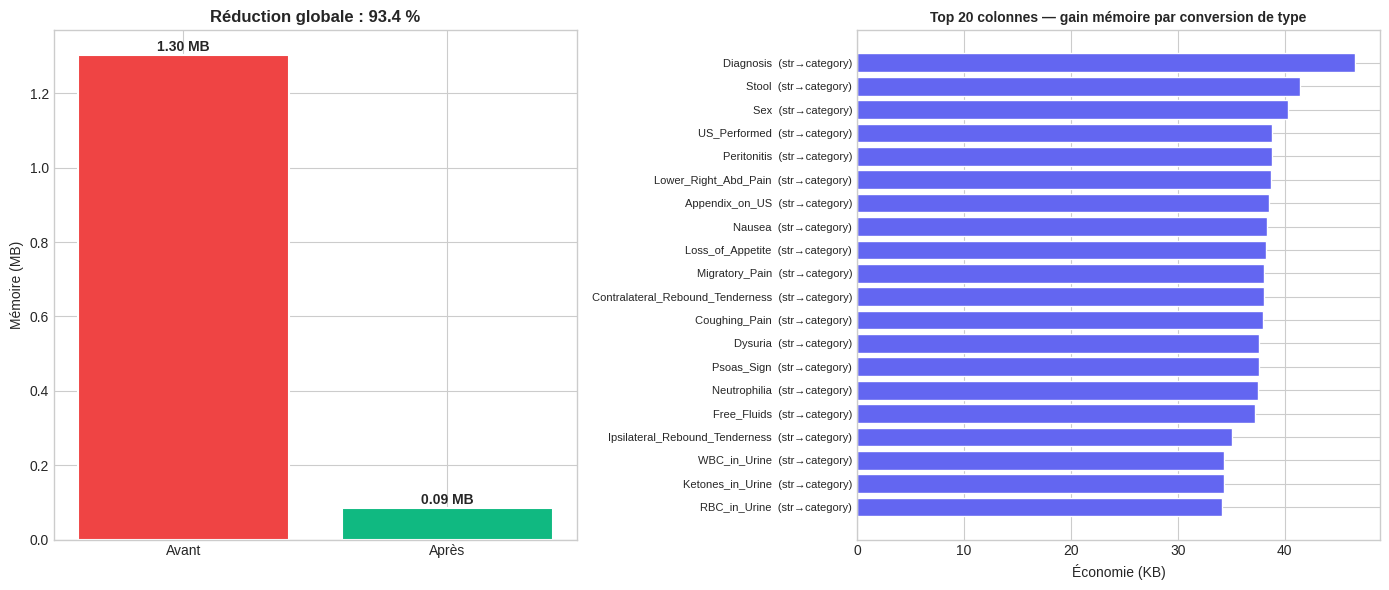

In [23]:
mem_before = df.memory_usage(deep=True).sum() / 1024**2
df_opt = optimize_memory(df)
mem_after = df_opt.memory_usage(deep=True).sum() / 1024**2
reduction = (1 - mem_after / mem_before) * 100

print(f'\nMemory BEFORE: {mem_before:.2f} MB')
print(f'Memory AFTER:  {mem_after:.2f} MB')
print(f'Reduction:     {reduction:.1f}%')

# --- D\u00e9tail colonne par colonne : quels types ont chang\u00e9 ---
type_changes = []
for col in df.columns:
    t_before = str(df[col].dtype)
    t_after = str(df_opt[col].dtype)
    if t_before != t_after:
        kb_before = df[col].memory_usage(deep=True) / 1024
        kb_after = df_opt[col].memory_usage(deep=True) / 1024
        type_changes.append({
            'Column': col,
            'Before': t_before,
            'After': t_after,
            'KB_Before': round(kb_before, 1),
            'KB_After': round(kb_after, 1),
            'Saved_KB': round(kb_before - kb_after, 1),
        })

tc_df = pd.DataFrame(type_changes).sort_values('Saved_KB', ascending=False).reset_index(drop=True)
print(f'\n{len(tc_df)} colonnes dont le type a chang\u00e9 :')
display(tc_df)

# --- Barplot des gains colonne par colonne (top 20) ---
top_tc = tc_df.head(20)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: before / after global
bars = axes[0].bar(['Avant', 'Apr\u00e8s'], [mem_before, mem_after],
                   color=[C_APP, C_SAIN], edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('M\u00e9moire (MB)')
axes[0].set_title(f'R\u00e9duction globale : {reduction:.1f} %', fontweight='bold')
for bar, val in zip(bars, [mem_before, mem_after]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.2f} MB', ha='center', fontweight='bold')

# Right: column-level savings
axes[1].barh(range(len(top_tc)), top_tc['Saved_KB'], color=C_NEUTRE, edgecolor='white')
axes[1].set_yticks(range(len(top_tc)))
axes[1].set_yticklabels([f"{r['Column']}  ({r['Before']}\u2192{r['After']})"
                         for _, r in top_tc.iterrows()], fontsize=8)
axes[1].set_xlabel('\u00c9conomie (KB)')
axes[1].set_title('Top 20 colonnes \u2014 gain m\u00e9moire par conversion de type', fontweight='bold', fontsize=10)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'memory_optimization.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Distributions by Diagnosis

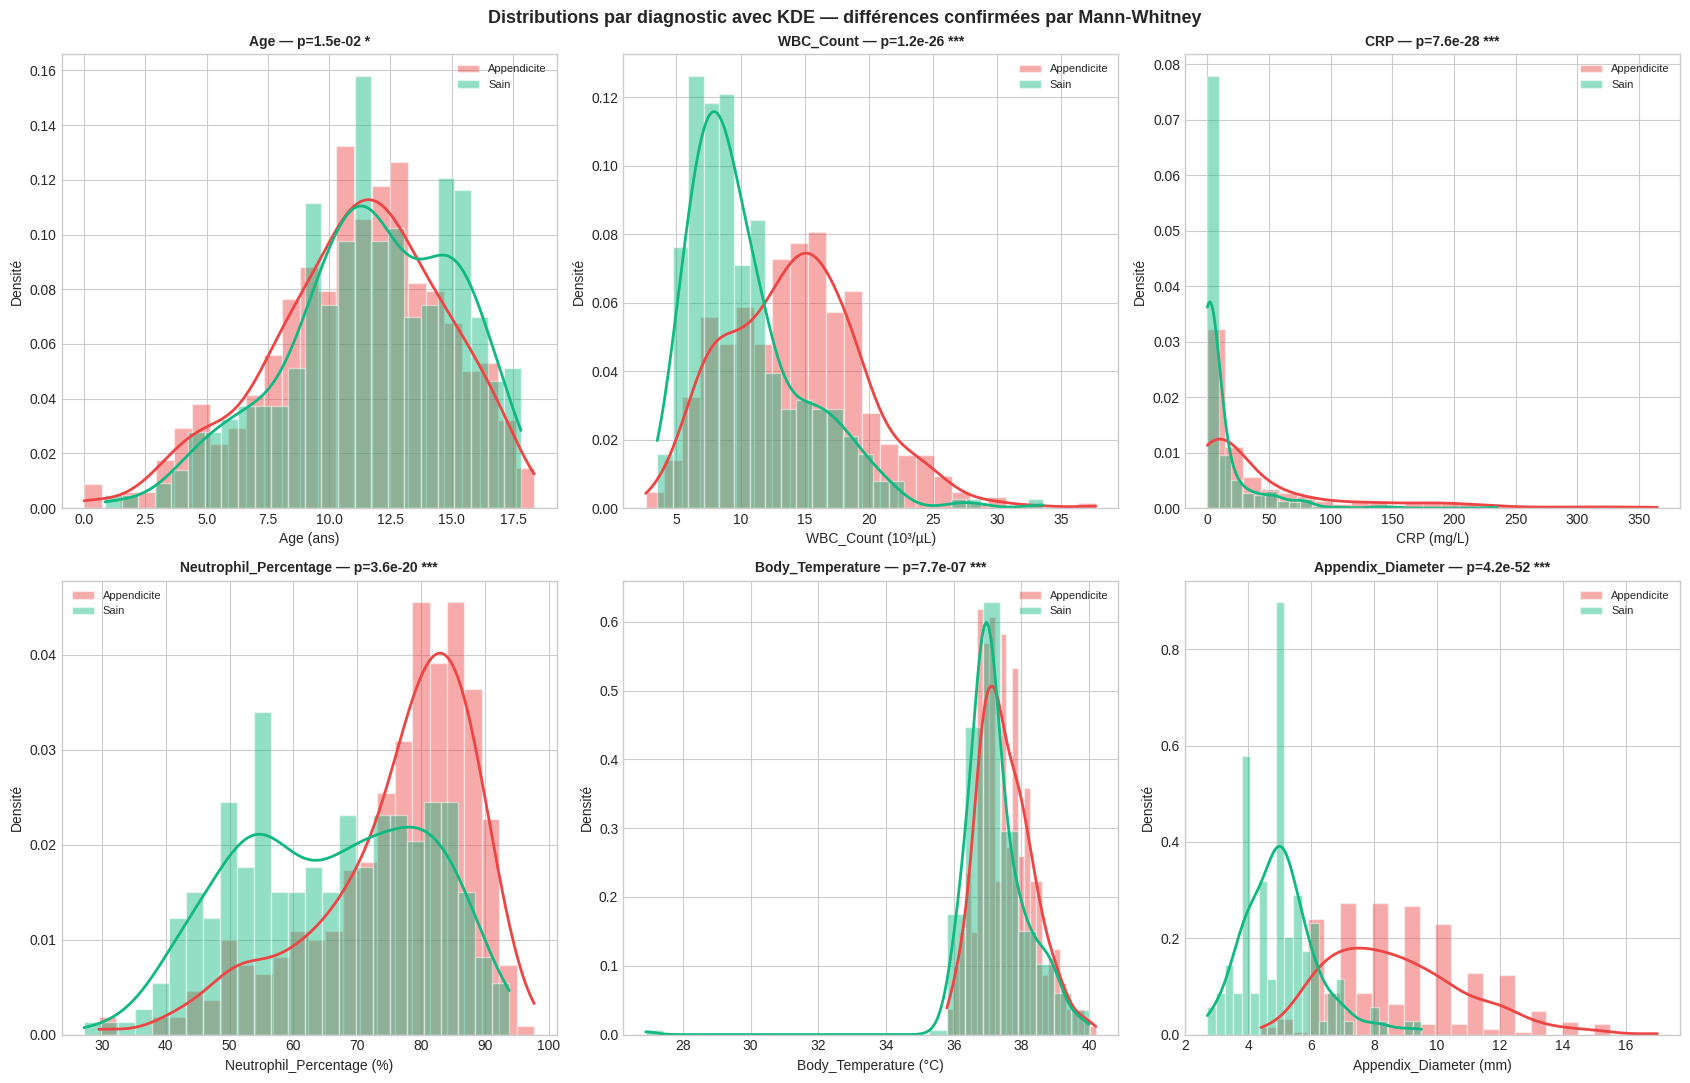

In [24]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
axes = axes.flatten()
plot_features = ['Age', 'WBC_Count', 'CRP', 'Neutrophil_Percentage', 'Body_Temperature', 'Appendix_Diameter']

for i, col in enumerate(plot_features):
    if col not in df.columns:
        continue

    grp_app = df.loc[df['Diagnosis'] == 'appendicitis', col].dropna()
    grp_sain = df.loc[df['Diagnosis'] == 'no appendicitis', col].dropna()

    for data, lbl, clr in [(grp_app, 'Appendicite', C_APP),
                            (grp_sain, 'Sain', C_SAIN)]:
        axes[i].hist(data, bins=25, alpha=0.45, label=lbl, color=clr, edgecolor='white', density=True)
        if len(data) > 2:
            xs = np.linspace(data.min(), data.max(), 200)
            kde = gaussian_kde(data)
            axes[i].plot(xs, kde(xs), color=clr, linewidth=2)

    if len(grp_app) > 0 and len(grp_sain) > 0:
        stat, pval = mannwhitneyu(grp_app, grp_sain, alternative='two-sided')
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        axes[i].set_title(f'{col} \u2014 p={pval:.1e} {sig}', fontweight='bold', fontsize=10)
    else:
        axes[i].set_title(col, fontweight='bold')

    axes[i].set_xlabel(label_with_unit(col))
    axes[i].set_ylabel('Densit\u00e9')
    axes[i].legend(fontsize=8)

plt.suptitle('Distributions par diagnostic avec KDE \u2014 diff\u00e9rences confirm\u00e9es par Mann-Whitney',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'distributions_by_diagnosis.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary

Key findings:
1. **Missing values**: 53 columns affected. Treated with median/mode imputation.
2. **Class balance**: ~59/41% split. Using balanced class weights.
3. **Outliers**: Present in lab results (WBC, CRP). Capped via IQR.
4. **Correlations**: WBC Count and Neutrophil % moderately correlated. All pairs with |r| > 0.5 visualized.
5. **Memory**: 93.4% reduction achieved via `optimize_memory()`, detailed column-by-column.
6. **Statistical tests**: Mann-Whitney U confirms significant differences (p<0.05) for WBC, CRP, Neutrophils, and Appendix Diameter between groups.

All figures saved to `reports/figures/`.